# Simulating

Fitting Models on 500 Data Points...


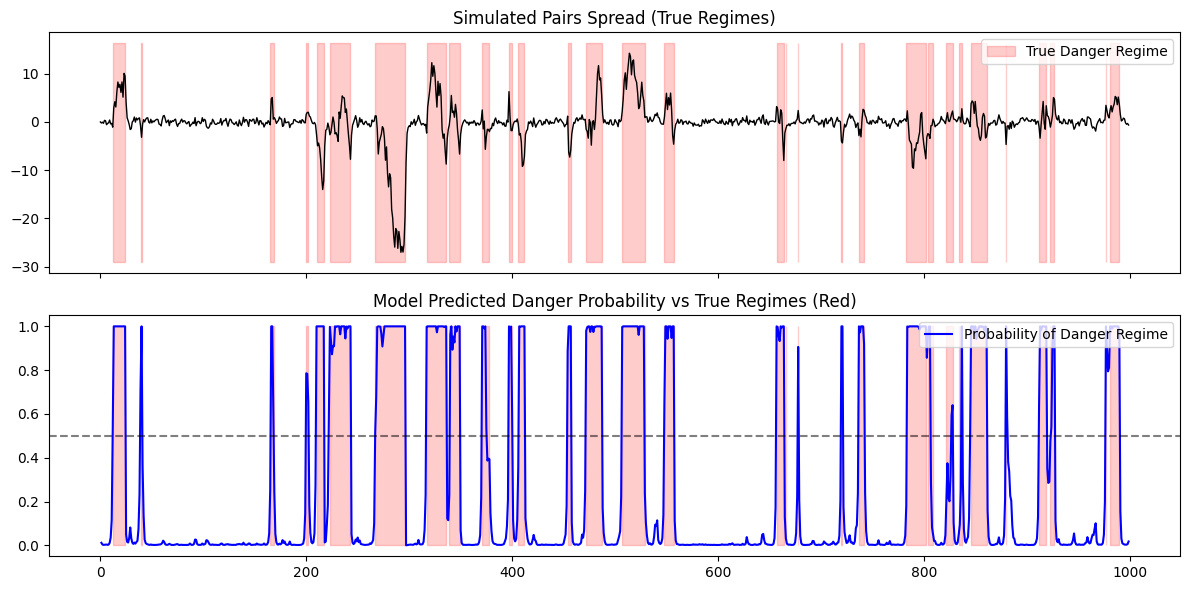

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.regime_switching.markov_autoregression import MarkovAutoregression

np.random.seed(101)

# --- 1. Simulate Pairs Trading Spread ---
N = 1000
# Calm: Spread mean-reverts quickly (phi=0.4), tight variance
# Danger: Spread breaks, random walk (phi=0.98), high variance
P = np.array([[0.95, 0.05], [0.10, 0.90]])
phi_true = np.array([0.40, 0.98])
sig_true = np.array([0.5, 2.5])

states = np.zeros(N, dtype=int)
spread = np.zeros(N)

for t in range(1, N):
    states[t] = np.random.choice([0, 1], p=P[states[t-1]])
    s = states[t]
    # Spread formula
    spread[t] = phi_true[s] * spread[t-1] + sig_true[s] * np.random.randn()

# --- 2. Fit Models ---
print("Fitting Models on 500 Data Points...")
ar_res = AutoReg(spread, lags=1, trend="c").fit()
ms_res = MarkovAutoregression(
    spread, k_regimes=2, order=1, trend="c", 
    switching_ar=True, switching_variance=True
).fit(search_reps=20, disp=False)

# --- 3. Evaluate & Plot ---
# Find which state is "Danger" by looking at the highest variance
params = dict(zip(ms_res.model.param_names, ms_res.params))
if params.get('sigma2[0]', 0) > params.get('sigma2[1]', 0):
    danger_state = 0
else:
    danger_state = 1

# THE FIX: Handle NumPy array directly and account for the dropped lag
probs = ms_res.smoothed_marginal_probabilities
if isinstance(probs, pd.DataFrame):
    probs = probs.values

danger_probs = probs[:, danger_state]
time_axis = np.arange(1, N) # Starts at 1 because AR(1) drops index 0

# --- Plotting ---
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Top Panel
ax[0].plot(np.arange(N), spread, color='black', linewidth=1)
ax[0].fill_between(np.arange(N), ax[0].get_ylim()[0], ax[0].get_ylim()[1],
                   where=(states==1), color='red', alpha=0.2, label='True Danger Regime')
ax[0].set_title('Simulated Pairs Spread (True Regimes)')
ax[0].legend(loc='upper right')

# Bottom Panel
ax[1].plot(time_axis, danger_probs, color='blue', label='Probability of Danger Regime')
ax[1].axhline(0.5, color='k', linestyle='--', alpha=0.5)
ax[1].fill_between(np.arange(N), 0, 1, where=(states==1), color='red', alpha=0.2)
ax[1].set_title('Model Predicted Danger Probability vs True Regimes (Red)')
ax[1].legend(loc='upper right')

plt.tight_layout()
plt.show()


Constructing Spread via OLS...
Fitting Markov Autoregression to Real Spread...


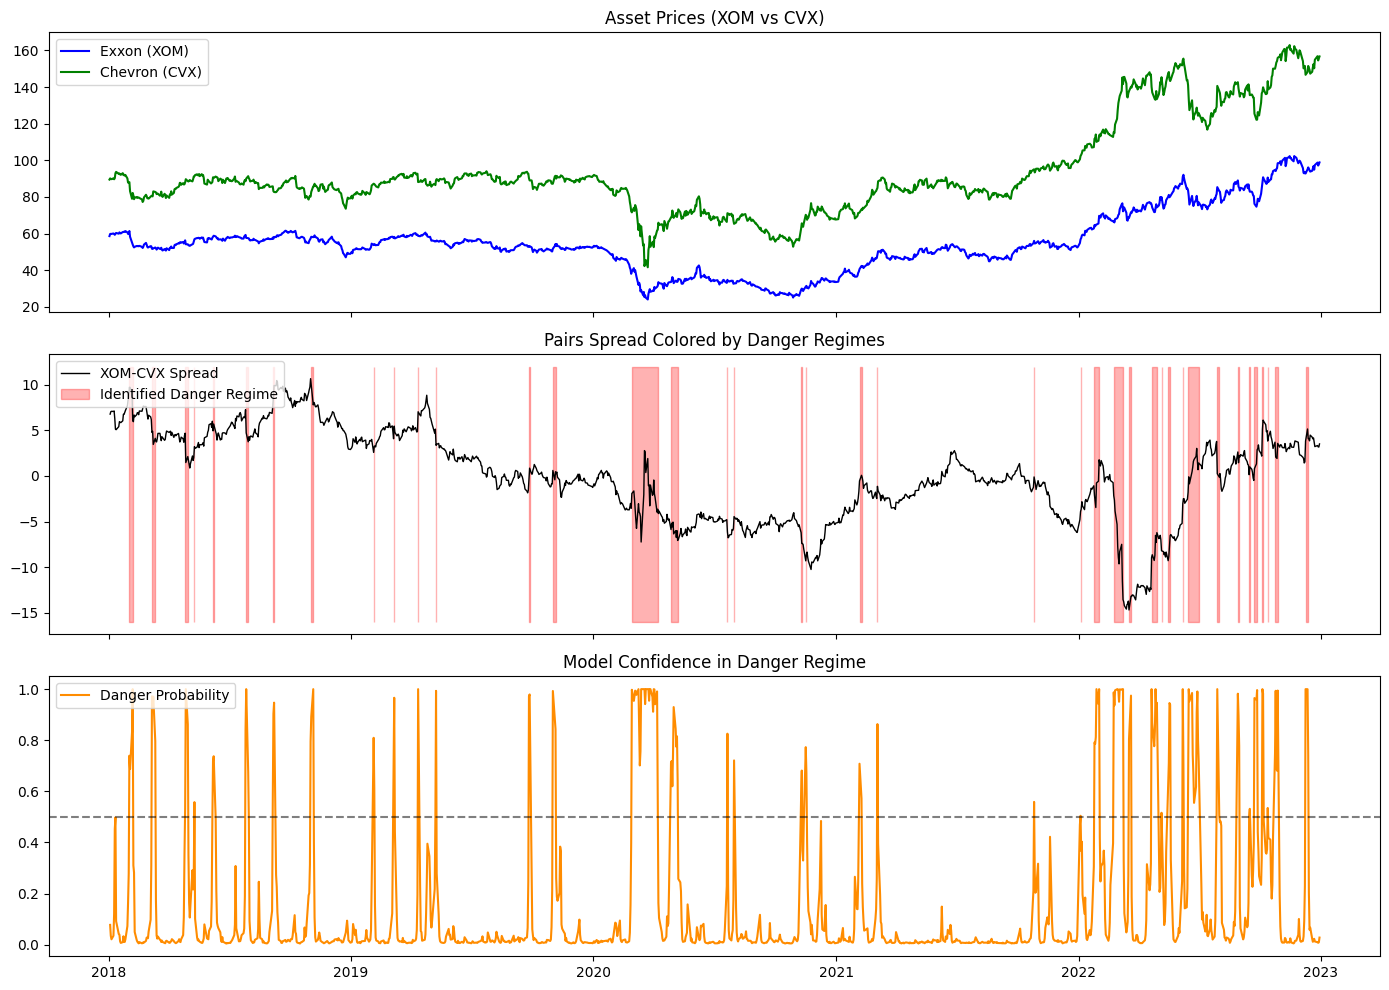


--- Real Data Parameters ---
Danger Regime AR(1): 0.9668
Danger Regime Vol:   1.2851
Calm Regime AR(1):   0.9973
Calm Regime Vol:     0.3783


In [10]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.regime_switching.markov_autoregression import MarkovAutoregression

# --- 1. Fetch Real Data (Bulletproof Method) ---
print("\nDownloading XOM and CVX data...")
# Downloading individually prevents yfinance's MultiIndex errors
xom = yf.download("XOM", start="2018-01-01", end="2023-01-01", progress=False)
cvx = yf.download("CVX", start="2018-01-01", end="2023-01-01", progress=False)

# Safely grab 'Close' (or 'Adj Close' if your version still has it)
col = 'Adj Close' if 'Adj Close' in xom.columns else 'Close'

data = pd.concat([xom[col], cvx[col]], axis=1)
data.columns = ['XOM', 'CVX']
data = data.dropna()

# --- 2. Construct the Spread ---
print("Constructing Spread via OLS...")
Y = data['XOM']
X = sm.add_constant(data['CVX'])
ols_res = sm.OLS(Y, X).fit()
real_spread = ols_res.resid.values

# --- 3. Fit the Markov Model on Real Data ---
print("Fitting Markov Autoregression to Real Spread...")
real_ms_model = MarkovAutoregression(
    real_spread, k_regimes=2, order=1, trend="c", 
    switching_ar=True, switching_variance=True
)
real_ms_res = real_ms_model.fit(search_reps=30, em_iter=50, disp=False)

# --- 4. Identify the Danger Regime ---
real_params = dict(zip(real_ms_res.model.param_names, real_ms_res.params))
var_0 = real_params.get('sigma2[0]', 0)
var_1 = real_params.get('sigma2[1]', 0)

danger_state = 0 if var_0 > var_1 else 1

probs = real_ms_res.smoothed_marginal_probabilities
if isinstance(probs, pd.DataFrame):
    probs = probs.values
danger_probs = probs[:, danger_state]

# --- 5. Plotting Real Data Results ---
time_axis = data.index[1:] # Drop first obs due to AR(1)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Panel 1: Underlying Assets
axes[0].plot(data.index, data['XOM'], label='Exxon (XOM)', color='blue')
axes[0].plot(data.index, data['CVX'], label='Chevron (CVX)', color='green')
axes[0].set_title('Asset Prices (XOM vs CVX)')
axes[0].legend(loc='upper left')

# Panel 2: The Spread & The Regimes
axes[1].plot(time_axis, real_spread[1:], color='black', linewidth=1, label='XOM-CVX Spread')
axes[1].fill_between(time_axis, axes[1].get_ylim()[0], axes[1].get_ylim()[1],
                     where=(danger_probs > 0.5), color='red', alpha=0.3, label='Identified Danger Regime')
axes[1].set_title('Pairs Spread Colored by Danger Regimes')
axes[1].legend(loc='upper left')

# Panel 3: Probability of Danger
axes[2].plot(time_axis, danger_probs, color='darkorange', label='Danger Probability')
axes[2].axhline(0.5, color='k', linestyle='--', alpha=0.5)
axes[2].set_title('Model Confidence in Danger Regime')
axes[2].legend(loc='upper left')

plt.tight_layout()
plt.show()

print("\n--- Real Data Parameters ---")
print(f"Danger Regime AR(1): {real_params.get(f'ar.L1[{danger_state}]', np.nan):.4f}")
print(f"Danger Regime Vol:   {np.sqrt(real_params.get(f'sigma2[{danger_state}]', np.nan)):.4f}")
print(f"Calm Regime AR(1):   {real_params.get(f'ar.L1[{1-danger_state}]', np.nan):.4f}")
print(f"Calm Regime Vol:     {np.sqrt(real_params.get(f'sigma2[{1-danger_state}]', np.nan)):.4f}")